In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

K: 0.0013347016023412227 (m/s), erreur K: +/- 4.695309623566461e-05
k: 1.3632786493897303e-10 (m^2), erreur k: +/- 1.531990170896851e-12


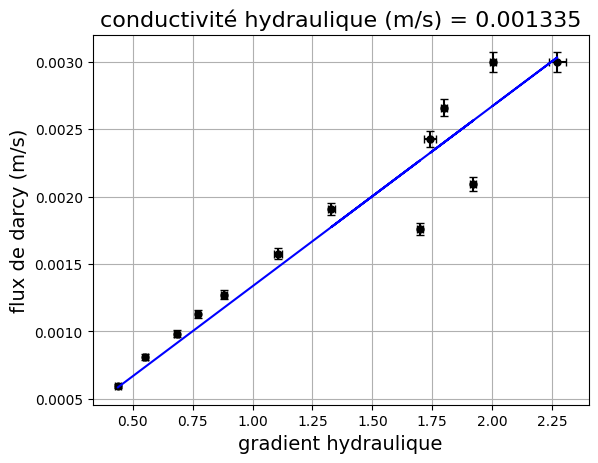

In [25]:
darcy_url = 'https://raw.githubusercontent.com/onillonn/TP_geologie/main/loi_darcy.xlsx'
darcy = pd.read_excel(darcy_url)
Q = darcy['débit_(m^3/s)'].dropna()
q = darcy['flux_Darcy_(m/s)'].dropna()
q_err = darcy['erreur_q'].dropna()
i = darcy['gradient'].dropna()
i_err = darcy['erreur_i'].dropna()

#graphe
fig, ax = plt.subplots()
ax.plot(i,q,'k',marker='o', linestyle='none',linewidth=0,markersize=5)
ax.errorbar(i,q,yerr=[q_err],xerr=[i_err],c='k',linestyle='none',capsize=3)
ax.set_xlabel('gradient hydraulique',fontsize=14)
ax.set_ylabel('flux de darcy (m/s)',fontsize=14)
ax.grid()

#ligne de régression, K
from scipy.optimize import curve_fit
def function_for_fit(x,a): #fonction à ajouter, x est la variable, a le paramètre
    return a*x
popt,pcov = curve_fit(function_for_fit,i,q)
K = popt.squeeze()
K_err = np.sqrt(pcov).squeeze()
ax.plot(i,function_for_fit(i,K),'b')
print (f"K: {K} (m/s), erreur K: +/- {K_err}")
ax.set_title(f"conductivité hydraulique (m/s) = {K:.6f}",fontsize=16)

#perméabilité intrinsèque
mu, rho, g = 0.001, 998, 9.81
mu_err = 0.0001
k = K * mu / g / rho
k_err = k*((K_err/K)**2+(mu_err/mu)**2)
print (f"k: {k} (m^2), erreur k: +/- {k_err}")



K: 0.0014530382921427998 (m/s), erreur K: +/- 1.2853341112277902e-05
k: 1.4841490239835427e-10 (m^2), erreur k: +/- 1.4957623189958657e-12


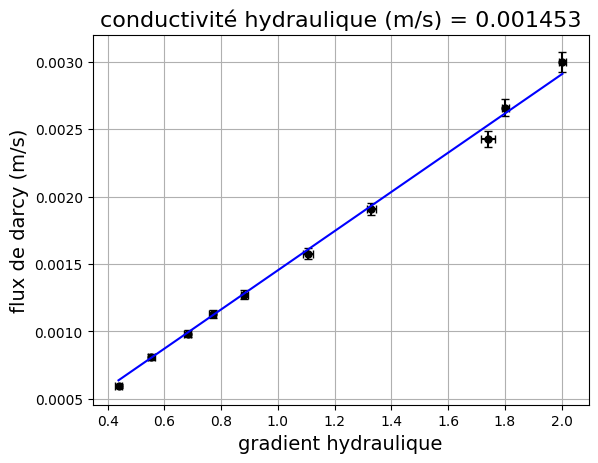

In [26]:
darcy_url = 'https://raw.githubusercontent.com/onillonn/TP_geologie/main/loi_darcy_corrige.xlsx'
darcy = pd.read_excel(darcy_url)
Q = darcy['débit_(m^3/s)'].dropna()
q = darcy['flux_Darcy_(m/s)'].dropna()
q_err = darcy['erreur_q'].dropna()
i = darcy['gradient'].dropna()
i_err = darcy['erreur_i'].dropna()

#graphe
fig, ax = plt.subplots()
ax.plot(i,q,'k',marker='o', linestyle='none',linewidth=0,markersize=5)
ax.errorbar(i,q,yerr=[q_err],xerr=[i_err],c='k',linestyle='none',capsize=3)
ax.set_xlabel('gradient hydraulique',fontsize=14)
ax.set_ylabel('flux de darcy (m/s)',fontsize=14)
ax.grid()

#ligne de régression, K
from scipy.optimize import curve_fit
def function_for_fit(x,a): #fonction à ajouter, x est la variable, a le paramètre
    return a*x
popt,pcov = curve_fit(function_for_fit,i,q)
K = popt.squeeze()
K_err = np.sqrt(pcov).squeeze()
ax.plot(i,function_for_fit(i,K),'b')
print (f"K: {K} (m/s), erreur K: +/- {K_err}")
ax.set_title(f"conductivité hydraulique (m/s) = {K:.6f}",fontsize=16)

#perméabilité intrinsèque
mu, rho, g = 0.001, 998, 9.81
mu_err = 0.0001
k = K * mu / g / rho
k_err = k*((K_err/K)**2+(mu_err/mu)**2)
print (f"k: {k} (m^2), erreur k: +/- {k_err}")